# Análise Exploratória dos Dados (EDA)

Este notebook apresenta uma análise exploratória do dataset **Online Retail**. O objetivo é compreender a estrutura dos dados, identificar variáveis-chave, avaliar a presença de valores ausentes e explorar algumas distribuições temporais e demográficas. Essa etapa é fundamental para orientar as decisões de pré-processamento e modelagem no sistema de recomendação.

## Carregamento do dataset

Primeiro carregamos o arquivo Excel usando `pandas.read_excel` e verificamos as primeiras linhas para entender os campos disponíveis. As colunas importantes são:

* **InvoiceNo** – identificador da fatura;
* **StockCode** – identificador do item;
* **Description** – descrição textual do item;
* **Quantity** – quantidade de unidades compradas;
* **InvoiceDate** – data e hora da compra;
* **UnitPrice** – preço unitário;
* **CustomerID** – identificador do cliente;
* **Country** – país de origem do cliente.

In [1]:
import pandas as pd

file_path = "../data/Online Retail.xlsx"

df = pd.read_excel(file_path, sheet_name="Online Retail")

# Primeiras linhas do DataFrame
print("Primeiras linhas do DataFrame:")
display(df.head())

Primeiras linhas do DataFrame:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# Informações gerais do DataFrame
print("\nInformações gerais do DataFrame:") 
print(df.info())


Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None


In [3]:
# Valores nulos em cada coluna
print("\nValores nulos em cada coluna:")
print(df.isnull().sum())


Valores nulos em cada coluna:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [25]:
# Estatísticas descritivas do DataFrame
print("\nEstatísticas descritivas das variáveis numéricas do DataFrame:")
df[['Quantity', 'UnitPrice']].describe()


Estatísticas descritivas das variáveis numéricas do DataFrame:


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [5]:
#Número de customersIDs nulos
print("\nNúmero de CustomerIDs nulos:")
print(df['CustomerID'].isnull().sum())

#Verificar quantos CustomersIDs não nulos existem
print("\nNúmero de CustomerIDs não nulos:")
print(df['CustomerID'].notnull().sum())

# Número total de registros
print("\nNúmero total de registros:")
print(len(df))



Número de CustomerIDs nulos:
135080

Número de CustomerIDs não nulos:
406829

Número total de registros:
541909


No dataframe temos muitos registros sem o CustomerID, isso pode indicar que muito das compras são de pessoas que não tem cadastro na loja.

### Compradores da loja

In [6]:
# Número de compradores da loja
print("\nNúmero de compradores da loja:")
print(df['CustomerID'].nunique())


Número de compradores da loja:
4372


### Números de produtos da loja
É possível notar que alguns produtos tem negativo ou igual a zero, significa que é uma compra de teste ou promoções, bom para remover na limpeza

In [27]:
print("\nNúmero de produtos da loja:")
print(df['StockCode'].nunique())

print("\nUnitPrice negativo ou igual a zero:")
print(df[df['UnitPrice'] <= 0].shape[0])

print(df[df['UnitPrice'] <= 0])


Número de produtos da loja:
4070

UnitPrice negativo ou igual a zero:
2517
       InvoiceNo StockCode                   Description  Quantity  \
622       536414     22139                           NaN        56   
1970      536545     21134                           NaN         1   
1971      536546     22145                           NaN         1   
1972      536547     37509                           NaN         1   
1987      536549    85226A                           NaN         1   
...          ...       ...                           ...       ...   
536981    581234     72817                           NaN        27   
538504    581406    46000M  POLYESTER FILLER PAD 45x45cm       240   
538505    581406    46000S  POLYESTER FILLER PAD 40x40cm       300   
538554    581408     85175                           NaN        20   
538919    581422     23169                       smashed      -235   

               InvoiceDate  UnitPrice  CustomerID         Country  
622    2010-12-

### Itens com preço igual a zero e com descrição
Muito provavelmente são promoções

In [8]:
# Quantos têm CustomerID e descrição?
df[(df['UnitPrice'] == 0) & df['CustomerID'].notnull() & df['Description'].notnull()].shape[0]


40

### Quantidades negativas no registro da compra
- Quantidades negativas indicam em compras significam devoluções/estornos/compras canceladas
- É possível perceber que o InvoiceNo começando com C(exemplo: C123456), C de creditNote

In [9]:
# Verificar se existem quantidades negativas
print("\nQuantidade negativa:")
print(df[df['Quantity'] < 0].shape[0])

print(df[df['Quantity'] < 0])



Quantidade negativa:
10624
       InvoiceNo StockCode                       Description  Quantity  \
141      C536379         D                          Discount        -1   
154      C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235      C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236      C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237      C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   
...          ...       ...                               ...       ...   
540449   C581490     23144   ZINC T-LIGHT HOLDER STARS SMALL       -11   
541541   C581499         M                            Manual        -1   
541715   C581568     21258        VICTORIAN SEWING BOX LARGE        -5   
541716   C581569     84978  HANGING HEART JAR T-LIGHT HOLDER        -1   
541717   C581569     20979     36 PENCILS TUBE RED RETROSPOT        -5   

               InvoiceDate  UnitPrice  CustomerID         Country  
141    2010-12-

## Distribuição de interações

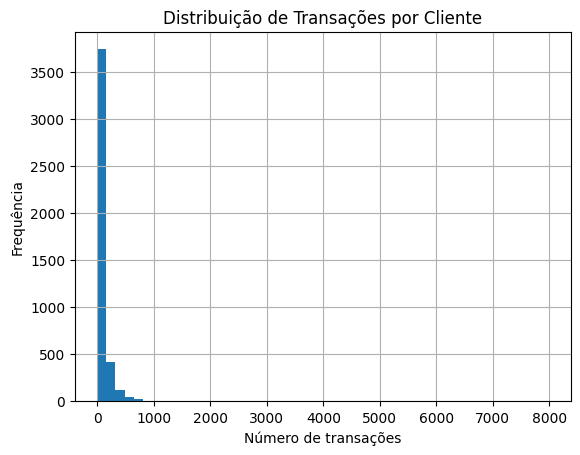

In [28]:
import matplotlib.pyplot as plt

df.groupby('CustomerID').size().hist(bins=50)
plt.xlabel('Número de transações')
plt.ylabel('Frequência')
plt.title('Distribuição de Transações por Cliente')
plt.show()

> Muitos usuários com poucas compras e poucos usuários com histórico muito grande.

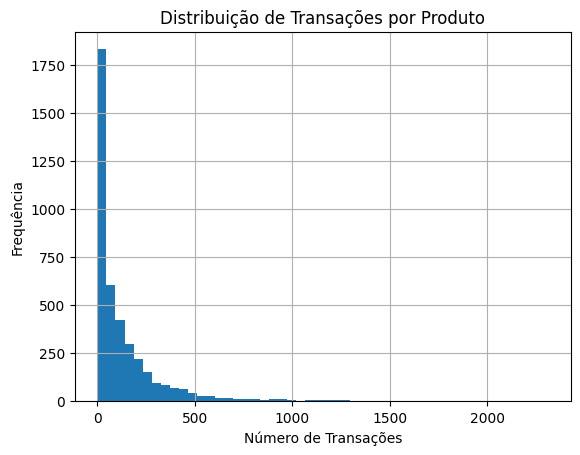

In [15]:
df.groupby('StockCode').size().hist(bins=50)
plt.xlabel('Número de Transações')
plt.ylabel('Frequência')
plt.title('Distribuição de Transações por Produto')
plt.show()


> Muitos itens são pouco comprados, poucos itens foram muito comprados

## Top produtos e top usuários

In [16]:
top_items = df['Description'].value_counts().head(10)
top_users = df['CustomerID'].value_counts().head(10)

print("Top 10 produtos:\n", top_items)
print("\nTop 10 usuários:\n", top_users)

Top 10 produtos:
 Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64

Top 10 usuários:
 CustomerID
17841.0    7983
14911.0    5903
14096.0    5128
12748.0    4642
14606.0    2782
15311.0    2491
14646.0    2085
13089.0    1857
13263.0    1677
14298.0    1640
Name: count, dtype: int64


## Análise temporal

2010-12-01 08:26:00 2011-12-09 12:50:00


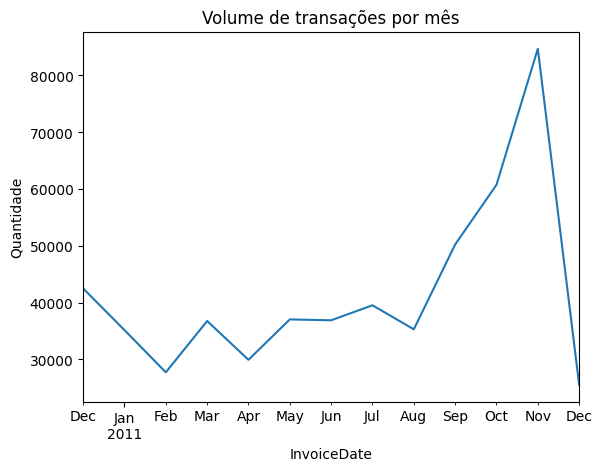

In [17]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(df['InvoiceDate'].min(), df['InvoiceDate'].max())

df.set_index('InvoiceDate').resample('ME').size().plot()
plt.title('Volume de transações por mês')
plt.ylabel('Quantidade')
plt.show()


## Sparsidade da matriz usuário-item

In [18]:
n_users = df['CustomerID'].nunique()
n_items = df['StockCode'].nunique()
n_interactions = len(df)

density = n_interactions / (n_users * n_items)
print(f"Sparsidade: {100*(1-density):.2f}%")


Sparsidade: 96.95%


### Analise da qualidade do conteúdo textual da coluna 'Description'

In [19]:
n_item_descriptions = df_clean['Description'].nunique()

print(f"Número de descrições únicas de itens: {n_item_descriptions}")
print(f"Número de itens únicos: {n_items}")

Número de descrições únicas de itens: 3877
Número de itens únicos: 4070


### Detectar descrições genéricas
> Objetivo: encontrar palavras que não descrevem bem o produto e aparecem em excesso.

In [20]:
word_counts = {}
words_in_descriptions = {}

item_descriptions = df_clean['Description'].unique()
item_descriptions = [str(desc).upper() for desc in item_descriptions]

for desc in item_descriptions:
    words = desc.split()
    words_in_descriptions[desc] = len(words)
    for word in words:
        word = word.strip(",.!?;:")
        word_counts[word] = word_counts.get(word, 0) + 1
            
# ver a lista de palavras que mais aparecem
sorted_word_counts = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
sorted_word_counts[:40]



[('PINK', 286),
 ('SET', 280),
 ('OF', 238),
 ('HEART', 236),
 ('VINTAGE', 215),
 ('BLUE', 210),
 ('RED', 194),
 ('BAG', 164),
 ('GLASS', 149),
 ('CHRISTMAS', 148),
 ('BOX', 134),
 ('WHITE', 128),
 ('DESIGN', 127),
 ('HOLDER', 116),
 ('SMALL', 113),
 ('FLOWER', 112),
 ('METAL', 111),
 ('LARGE', 102),
 ('HANGING', 101),
 ('ROSE', 99),
 ('DECORATION', 98),
 ('WALL', 97),
 ('RETROSPOT', 96),
 ('GREEN', 94),
 ('BLACK', 94),
 ('3', 92),
 ('CANDLE', 92),
 ('T-LIGHT', 89),
 ('PAPER', 84),
 ('NECKLACE', 84),
 ('CAKE', 83),
 ('SILVER', 83),
 ('CARD', 80),
 ('WITH', 79),
 ('AND', 78),
 ('ART', 77),
 ('POLKADOT', 71),
 ('GARDEN', 71),
 ('IN', 71),
 ('MUG', 69)]

### Comprimento médio das descrições
> Objetivo: ver se o texto é curto demais

In [21]:
# Média de palavras por descrição
mean_words = sum(words_in_descriptions.values()) / len(words_in_descriptions) if words_in_descriptions else 0
# Máximo de palavras por descrição
max_words = max(words_in_descriptions.values()) if words_in_descriptions else 0
# Mínimo de palavras por descrição
min_words = min(words_in_descriptions.values()) if words_in_descriptions else 0

print(f'Média de palavras por descrição: {mean_words}')
print(f'Máximo de palavras por descrição: {max_words}')
print(f'Mínimo de palavras por descrição: {min_words}')


Média de palavras por descrição: 4.365746711374774
Máximo de palavras por descrição: 8
Mínimo de palavras por descrição: 1


### Riqueza do vocabulário
> Objetivo: saber se há muita repetição ou se o vocabulário é variado.

In [22]:
num_total_words = sum(words_in_descriptions.values())
unique_words = len(word_counts)
vocabulary_richness = unique_words / num_total_words 

print(f'Número total de palavras nas descrições: {num_total_words}')
print(f'Número de palavras únicas nas descrições: {unique_words}')
print(f'Riqueza vocabular: {vocabulary_richness}')


Número total de palavras nas descrições: 16926
Número de palavras únicas nas descrições: 2207
Riqueza vocabular: 0.130391114262082


### Salvar o dataset limpo como um novo dataset .parquet

In [23]:
df_clean['StockCode'] = df_clean['StockCode'].astype(str)
df_clean.to_parquet("../data/online_retail_clean.parquet", index=False)